In [1]:
from datetime import date

import matplotlib.pyplot as plt
import numpy as np

from metr import fit_metr, load_metr_data

In [2]:
df = load_metr_data("data/benchmark_results.yaml")

fit_p50 = fit_metr(df, horizon="p50")
fit_p80 = fit_metr(df, horizon="p80")

print("p50 horizon:")
print(f"  Doubling time: {fit_p50.doubling_time_months:.2f} months")
print(f"  R² = {fit_p50.r_squared:.3f}")
print()
print("p80 horizon:")
print(f"  Doubling time: {fit_p80.doubling_time_months:.2f} months")
print(f"  R² = {fit_p80.r_squared:.3f}")

p50 horizon:
  Doubling time: 6.64 months
  R² = 0.888

p80 horizon:
  Doubling time: 6.72 months
  R² = 0.887


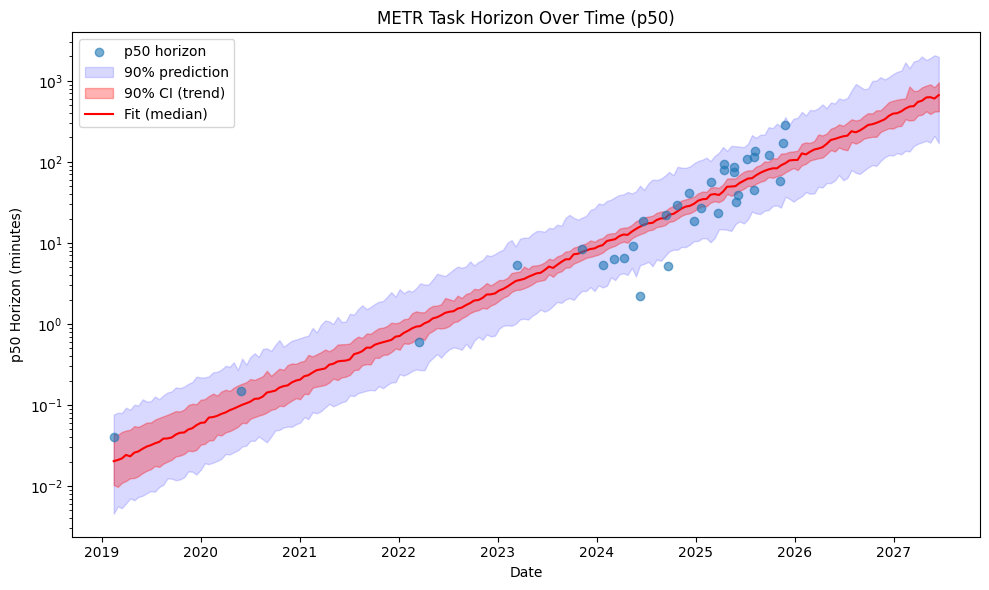

In [9]:
fit = fit_p50  # Change to fit_p80 to plot p80 horizon
horizon_col = f"{fit.horizon_type}_horizon"

fig, ax = plt.subplots(figsize=(10, 6))

# Data points
ax.scatter(
    df["release_date"], df[horizon_col], alpha=0.6, label=f"{fit.horizon_type} horizon", zorder=3
)

# Fit line with uncertainty bands
t_range = np.linspace(0, 100, 200)
dates = [date.fromordinal(fit.base_date.toordinal() + int(t * 30.44)) for t in t_range]

n_samples = 500

# Prediction interval (includes residual variance - should cover ~90% of data)
pred_horizons = np.array([fit.horizon_at_prediction(t, n=n_samples) for t in t_range])
pred_p5 = np.percentile(pred_horizons, 5, axis=1)
pred_p95 = np.percentile(pred_horizons, 95, axis=1)
ax.fill_between(dates, pred_p5, pred_p95, alpha=0.15, color="blue", label="90% prediction")

# Confidence interval for trend (uncertainty in fit parameters only)
trend_horizons = np.array([fit.horizon_at(t, n=n_samples) for t in t_range])
median = np.median(trend_horizons, axis=1)
trend_p5 = np.percentile(trend_horizons, 5, axis=1)
trend_p95 = np.percentile(trend_horizons, 95, axis=1)
ax.fill_between(dates, trend_p5, trend_p95, alpha=0.3, color="red", label="90% CI (trend)")

ax.plot(dates, median, "r-", label="Fit (median)")

ax.set_yscale("log")
ax.set_xlabel("Date")
ax.set_ylabel(f"{fit.horizon_type} Horizon (minutes)")
ax.set_title(f"METR Task Horizon Over Time ({fit.horizon_type})")
ax.legend()
plt.tight_layout()
plt.show()


In [10]:
for d in [date(2026, 1, 1), date(2027, 1, 1), date(2028, 1, 1)]:
    h50 = fit_p50.horizon_at_date(d, n=10000)
    h80 = fit_p80.horizon_at_date(d, n=10000)
    print(f"{d}:")
    print(
        f"  p50: {np.median(h50):6.0f} min ({np.median(h50) / 60:5.1f} hr) "
        f"[90% CI: {np.percentile(h50, 5):5.0f}-{np.percentile(h50, 95):5.0f}]"
    )
    print(
        f"  p80: {np.median(h80):6.0f} min ({np.median(h80) / 60:5.1f} hr) "
        f"[90% CI: {np.percentile(h80, 5):5.0f}-{np.percentile(h80, 95):5.0f}]"
    )


2026-01-01:
  p50:    111 min (  1.9 hr) [90% CI:    86-  145]
  p80:     20 min (  0.3 hr) [90% CI:    15-   26]
2027-01-01:
  p50:    387 min (  6.4 hr) [90% CI:   265-  550]
  p80:     69 min (  1.1 hr) [90% CI:    47-   99]
2028-01-01:
  p50:   1340 min ( 22.3 hr) [90% CI:   820- 2185]
  p80:    241 min (  4.0 hr) [90% CI:   147-  393]
